# Benchmark API - Evaluate Scenario Analysis

This notebook analyzes the benchmark results from the evaluate API, comparing different configurations (shapes, noise levels, permittivity, sources/measurements) across multiple algorithms.

In [ ]:
!pip install --upgrade eispy2d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.5/278.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 84.2 MB/s eta 0:00:00


In [ ]:
import sys
import os
import numpy as np
import scipy.sparse as sps
from numpy.linalg import inv

from eispy2d.api import testset_api as ts
from eispy2d.api import benchmark_api as bmk
from eispy2d.core import configuration as cfg
from eispy2d.core import inputdata as ipt
from eispy2d.discretization import richmond as ric
from eispy2d.solvers.inverse import bornapprox as ba
from eispy2d.solvers.inverse import bim
from eispy2d.solvers.inverse import csi
from eispy2d.solvers.inverse import regularization as reg
from eispy2d.solvers.forward import mom_cg_fft as mom
from eispy2d.utils import stopcriteria as stp


WAVELENGTH = 1.0
Lx, Ly = 0.8, 0.8
OBSERVATION_RADIUS = 1.0
RESOLUTION = (30, 30)
NOISE_LEVEL = 1.0
SAMPLE_SIZE = 15
BACKGROUND_PERMITTIVITY = 4.0


def born_approximation(scattered_field, incident_field, GS, GD, recover_resolution):
    NM, NS = scattered_field.shape
    config = cfg.Configuration(
        name='temp',
        wavelength=1.0,
        number_measurements=NM,
        number_sources=NS,
        image_size=[0.8, 0.8],
        observation_radius=1.0,
        background_permittivity=BACKGROUND_PERMITTIVITY,
        perfect_dielectric=True
    )
    discretization = ric.Richmond(config, recover_resolution, state=False)
    inputdata = ipt.InputData(
        name='temp',
        configuration=config,
        resolution=recover_resolution,
        scattered_field=scattered_field,
        incident_field=incident_field,
        indicators=[]
    )
    solver = ba.FirstOrderBornApproximation(reg.Tikhonov(1e-1))
    result = solver.solve(inputdata, discretization, print_info=False)
    chi = (result.rel_permittivity / config.epsilon_rb) - 1
    return result.scattered_field, chi


def born_iterative_method(scattered_field, incident_field, GS, GD, recover_resolution):
    NM, NS = scattered_field.shape
    config = cfg.Configuration(
        name='temp',
        wavelength=1.0,
        number_measurements=NM,
        number_sources=NS,
        image_size=[0.8, 0.8],
        observation_radius=1.0,
        background_permittivity=BACKGROUND_PERMITTIVITY,
        perfect_dielectric=True
    )
    discretization = ric.Richmond(config, recover_resolution, state=False)
    inputdata = ipt.InputData(
        name='temp',
        configuration=config,
        resolution=recover_resolution,
        scattered_field=scattered_field,
        incident_field=incident_field,
        indicators=[]
    )
    solver = bim.BornIterativeMethod(
        mom.MoM_CG_FFT(tolerance=0.01, maximum_iterations=2500),
        reg.Tikhonov(reg.TIK_FIXED, parameter=0.1),
        stp.StopCriteria(max_iterations=5))

    result = solver.solve(inputdata, discretization, print_info=False)
    chi = (result.rel_permittivity / config.epsilon_rb) - 1
    return result.scattered_field, chi


def contrast_source_inversion(scattered_field, incident_field, GS, GD, recover_resolution):
    NM, NS = scattered_field.shape
    config = cfg.Configuration(
        name='temp',
        wavelength=1.0,
        number_measurements=NM,
        number_sources=NS,
        image_size=[0.8, 0.8],
        observation_radius=1.0,
        background_permittivity=BACKGROUND_PERMITTIVITY,
        perfect_dielectric=True
    )
    discretization = ric.Richmond(config, recover_resolution, state=False)
    inputdata = ipt.InputData(
        name='temp',
        configuration=config,
        resolution=recover_resolution,
        scattered_field=scattered_field,
        incident_field=incident_field,
        indicators=[]
    )
    solver = csi.ContrastSourceInversion(
        stp.StopCriteria(max_iterations=100)
    )
    result = solver.solve(inputdata, discretization, print_info=False)
    chi = (result.rel_permittivity / config.epsilon_rb) - 1
    return result.scattered_field, chi


def sum_approximation(scattered_field, incident_field, GS, GD, recover_resolution):
    NM, NS = scattered_field.shape
    N_pixels = incident_field.shape[0]


    A = np.zeros((NM * NS, N_pixels), dtype=complex)

    b = scattered_field.reshape(-1, 1, order='F')

    for s in range(NS):
        E_inc_s = incident_field[:, s:s+1]


        A_s = GS * E_inc_s.T

        A[s * NM : (s + 1) * NM, :] = A_s

    gamma = 1e-3
    A_reg = A.conj().T @ A + (gamma ** 2) * np.eye(N_pixels)
    b_reg = A.conj().T @ b

    chi_flat = np.linalg.solve(A_reg, b_reg)

    E_recover = (A @ chi_flat).reshape(NM, NS, order='F')

    return E_recover, chi_flat.reshape(recover_resolution)


algorithms = [
    born_approximation,
    born_iterative_method,
    contrast_source_inversion,
    sum_approximation,
]

algorithm_names = [
    'Born Approximation',
    'Born Iterative Method',
    'Contrast Source Inversion',
    'Sum Approximation'
]


N_SHAPES = 13
N_NOISE_LEVELS = 15
N_PERMITTIVITIES = 15
N_SOURCE_PAIRS = 15

DEFAULT_SHAPE = "circle"
DEFAULT_NOISE = 1.0
DEFAULT_PERMITTIVITY = 4.0
DEFAULT_NM = 16
DEFAULT_NS = 16


def get_shapes():
    return [
        "triangle", "square", "circle", "ellipse", "cross",
        "star5", "star6", "rhombus", "trapezoid", "polygon",
        "random", "ring", "parallelogram"
    ]


def get_noise_levels():
    l = []
    for i in range(N_NOISE_LEVELS):
        l.append(i * (10.0 / (N_NOISE_LEVELS - 1)))
    return l


def get_permittivities():
    l = []
    for i in range(N_PERMITTIVITIES):
        l.append(1.0 + i * (10.0 / (N_PERMITTIVITIES - 1)))
    return l


def get_source_pairs():
    l = []
    for i in range(N_SOURCE_PAIRS+1):
        l.append((8 * (i % 3) + 8, 8 * (i // 3) + 8))
    return l


def generate_configurations():
    shapes = get_shapes()
    noise_levels = get_noise_levels()
    permittivities = get_permittivities()
    source_pairs = get_source_pairs()

    configs = []

    for shape in shapes:
        configs.append({
            "shape": shape,
            "background_permittivity": DEFAULT_PERMITTIVITY,
            "number_measurements": DEFAULT_NM,
            "number_sources": DEFAULT_NS,
            "noise_level": DEFAULT_NOISE
        })

    for noise in noise_levels:
        if noise == DEFAULT_NOISE:
            continue
        configs.append({
            "shape": DEFAULT_SHAPE,
            "background_permittivity": DEFAULT_PERMITTIVITY,
            "number_measurements": DEFAULT_NM,
            "number_sources": DEFAULT_NS,
            "noise_level": noise
        })

    for eps in permittivities:
        if eps == DEFAULT_PERMITTIVITY:
            continue
        configs.append({
            "shape": DEFAULT_SHAPE,
            "background_permittivity": eps,
            "number_measurements": DEFAULT_NM,
            "number_sources": DEFAULT_NS,
            "noise_level": DEFAULT_NOISE
        })

    for nm, ns in source_pairs:
        if nm == DEFAULT_NM and ns == DEFAULT_NS:
            continue
        configs.append({
            "shape": DEFAULT_SHAPE,
            "background_permittivity": DEFAULT_PERMITTIVITY,
            "number_measurements": nm,
            "number_sources": ns,
            "noise_level": DEFAULT_NOISE
        })

    return configs


configurations = generate_configurations()

print('=' * 70)
print('BENCHMARK GENERATOR - API EVALUATE')
print('=' * 70)

print('\nCreating test set...')

mytestset = ts.TestSet(
    name="benchmark_tests",
    wavelength=WAVELENGTH,
    image_size=(Lx, Ly),
    observation_radius=OBSERVATION_RADIUS,
    resolution=RESOLUTION,
    noise_level=NOISE_LEVEL,
    sample_size=SAMPLE_SIZE
)

mytestset.randomize_tests(parallelization=True)

print(f'Test set created: {mytestset.sample_size} test cases.')
print(f'Condition: {mytestset._testset_condition}')

print('\nCreating benchmark...')

mybenchmark = bmk.Benchmark(
    name="api_benchmark",
    algorithm=algorithms,
    testset=mytestset,
    configurations=configurations
)

print(f'Benchmark: {mybenchmark.name}')
print(f'Algorithms: {len(algorithms)}')
print(f'Test set: {mytestset.name}')
print(f'Configurations: {len(configurations)}')

print('\n' + '-' * 70)
print('Configuration summary:')
print('-' * 70)

shape_count = 0
noise_count = 0
perm_count = 0
src_count = 0

for c in configurations:
    shape = c.get('shape')
    nm = c.get('number_measurements', 16)
    ns = c.get('number_sources', 16)
    noise = c.get('noise_level', 1.0)
    eps = c.get('background_permittivity', 4.0)

    if nm == DEFAULT_NM and ns == DEFAULT_NS and noise == DEFAULT_NOISE and eps == DEFAULT_PERMITTIVITY:
        shape_count += 1
    elif shape == DEFAULT_SHAPE and eps == DEFAULT_PERMITTIVITY and nm == DEFAULT_NM and ns == DEFAULT_NS and noise != DEFAULT_NOISE:
        noise_count += 1
    elif shape == DEFAULT_SHAPE and nm == DEFAULT_NM and ns == DEFAULT_NS and noise == DEFAULT_NOISE and eps != DEFAULT_PERMITTIVITY:
        perm_count += 1
    elif shape == DEFAULT_SHAPE and eps == DEFAULT_PERMITTIVITY and noise == DEFAULT_NOISE and (nm != DEFAULT_NM or ns != DEFAULT_NS):
        src_count += 1

print(f'Shapes: {shape_count} configurations')
print(f'Noise levels: {noise_count} configurations')
print(f'Permittivity: {perm_count} configurations')
print(f'Sources/Measurements: {src_count} configurations')
print('-' * 70)

print('\nExecuting benchmark...')
print('This may take a while. Please wait...')

try:
    mybenchmark.run(parallelization=bmk.PARALLELIZE_TESTS)
    print('Benchmark completed successfully!')
except Exception as e:
    print(f'Error during benchmark execution: {e}')
    print('Saving partial results...')

print('\nResults:')
if hasattr(mybenchmark.results, 'shape'):
    print(f'Results shape: {mybenchmark.results.shape}')
else:
    print('Results shape: N/A')

if mybenchmark.results is not None:
    if isinstance(mybenchmark.results, np.ndarray):
        print(f'Format: {mybenchmark.results.shape}')
        if mybenchmark.results.size > 0:
            first_result = mybenchmark.results.flat[0]
            if hasattr(first_result, 'indicators'):
                print(f'Available indicators: {list(first_result.indicators.keys())}')
    else:
        print(f'Type: {type(mybenchmark.results)}')

print('\nSaving results...')
mybenchmark.save(save_testset=True)
print(f'Results saved to: {mybenchmark.name}')

print('\n' + '=' * 70)
print('Done!')
print('=' * 70)


BENCHMARK GENERATOR - API EVALUATE

Creating test set...
Test set created: 5 test cases.
Condition: Ready

Creating benchmark...
Benchmark: api_benchmark
Algorithms: 4
Test set: benchmark_tests
Configurations: 58

----------------------------------------------------------------------
Configuration summary:
----------------------------------------------------------------------
Shapes: 13 configurations
Noise levels: 15 configurations
Permittivity: 15 configurations
Sources/Measurements: 15 configurations
----------------------------------------------------------------------

Executing benchmark...
This may take a while. Please wait...
Benchmark completed successfully!

Results:
Results shape: (4, 58, 5)
Format: (4, 58, 5)

Saving results...
Results saved to: api_benchmark

Done!


In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

from eispy2d.api import benchmark_api as bmk
from eispy2d.core import result as rst

mybmk = bmk.Benchmark('void')
mybmk.importdata('api_benchmark')

In [ ]:
print(mybmk)

BENCHMARK (API)
Name: api_benchmark
Wavelength: None
Image size: None
Number measurements: None
Number sources: None
Observation radius: None
Resolution: None
Background permittivity: None
Noise level: None
Shape: None
Sample size: None
Results: done
Algorithm: None
Test set: benchmark_tests
Configurations: 58 configurations



## 1. Analysis of Results Structure

In [ ]:
algorithm_names = ['Born Approximation', 'Born Iterative Method', 'Contrast Source Inversion', 'Sum Contrast']
n_algorithms = len(algorithm_names)


results = np.asarray(mybmk.results)

print(f"Results shape: {results.shape}")

if results.ndim != 3:
    raise ValueError(
        f"Unexpected results shape {results.shape}. "
        "For this benchmark the expected shape is "
        "(n_algorithms, n_configurations, n_tests)."
    )

n_algorithms_results, n_configs_results, n_tests = results.shape

if n_algorithms_results != n_algorithms:
    raise ValueError(
        f"Number of algorithms in results ({n_algorithms_results}) "
        f"does not match algorithm_names ({n_algorithms})."
    )

configs = mybmk._configurations

if configs is None:
    raise ValueError("No configurations found in mybmk._configurations.")

n_configs = len(configs)

if n_configs_results != n_configs:
    raise ValueError(
        f"Results contain {n_configs_results} configurations, "
        f"but mybmk._configurations contains {n_configs}."
    )

print(f"Number of algorithms: {n_algorithms_results}")
print(f"Number of configurations: {n_configs_results}")
print(f"Number of test cases per configuration: {n_tests}")
print(f"Configuration metadata: {len(configs)}")


Results shape: (4, 58, 1)
Number of algorithms: 4
Number of configurations: 58
Number of test cases per configuration: 1
Configuration metadata: 58


In [ ]:
def extract_indicator(results, indicator):
    values = []
    for r in results:
        if hasattr(r, indicator):
            val = getattr(r, indicator)
            if isinstance(val, list) and len(val) > 0:
                values.append(val[-1])
            elif isinstance(val, (int, float)):
                values.append(val)
            else:
                values.append(np.nan)
        else:
            values.append(np.nan)
    return np.array(values)

In [ ]:
def get_config_label(config):
    label_parts = []

    if 'shape' in config:
        label_parts.append(f"shape={config['shape']}")
    if 'background_permittivity' in config:
        label_parts.append(f"eps={config['background_permittivity']}")
    if 'number_measurements' in config:
        label_parts.append(f"NM={config['number_measurements']}")
    if 'number_sources' in config:
        label_parts.append(f"NS={config['number_sources']}")
    if 'noise_level' in config:
        label_parts.append(f"noise={config['noise_level']}")

    return ", ".join(label_parts)


def get_result_data(algorithm_index, config_index):
    """Return the Result objects for one algorithm/configuration pair."""
    if not (0 <= algorithm_index < n_algorithms):
        raise IndexError("Invalid algorithm index.")
    if not (0 <= config_index < n_configs):
        raise IndexError("Invalid configuration index.")

    return results[algorithm_index, config_index, :]


def get_indicator_data(algorithm_index, config_index, indicator):
    """Extract one indicator from all tests of one algorithm/configuration."""
    return extract_indicator(
        get_result_data(algorithm_index, config_index),
        indicator
    )


## 2. Configuration Groups Analysis

In [ ]:
print("Configuration groups:")
print("-" * 60)

if n_configs != 312:
    print(f"Warning: expected 312 configurations, found {n_configs}.")

group_sizes = {
    'shapes': 13,
    'noise': 16,
    'permittivity': 16,
    'sources': 15,
}

group_indices = {}
start = 0

for name, size in group_sizes.items():
    end = min(start + size, n_configs)
    group_indices[name] = list(range(start, end))
    start = end

print(f"Total configurations available: {n_configs}")
print()

for name, indices in group_indices.items():
    print(f"{name.upper()}: {len(indices)} configurations")
    if indices:
        for i in indices[:3]:
            print(f"  {i}: {get_config_label(configs[i])}")
        if len(indices) > 3:
            print(f"  ... and {len(indices) - 3} more")
    print()

if start != n_configs:
    raise ValueError(
        f"Configuration groups cover {start} configurations, "
        f"but {n_configs} are available."
    )

print("-" * 60)
print("Configuration groups validated.")


Configuration groups:
------------------------------------------------------------
Total configurations available: 58

SHAPES: 13 configurations
  0: shape=triangle, eps=4.0, NM=16, NS=16, noise=1.0
  1: shape=square, eps=4.0, NM=16, NS=16, noise=1.0
  2: shape=circle, eps=4.0, NM=16, NS=16, noise=1.0
  ... and 10 more

NOISE: 16 configurations
  13: shape=circle, eps=4.0, NM=16, NS=16, noise=0.0
  14: shape=circle, eps=4.0, NM=16, NS=16, noise=0.7142857142857143
  15: shape=circle, eps=4.0, NM=16, NS=16, noise=1.4285714285714286
  ... and 13 more

PERMITTIVITY: 16 configurations
  29: shape=circle, eps=1.7142857142857144, NM=16, NS=16, noise=1.0
  30: shape=circle, eps=2.428571428571429, NM=16, NS=16, noise=1.0
  31: shape=circle, eps=3.142857142857143, NM=16, NS=16, noise=1.0
  ... and 13 more

SOURCES: 13 configurations
  45: shape=circle, eps=4.0, NM=24, NS=8, noise=1.0
  46: shape=circle, eps=4.0, NM=8, NS=16, noise=1.0
  47: shape=circle, eps=4.0, NM=24, NS=16, noise=1.0
  ... an

## 3. Shape Variation Analysis

Shape configuration indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


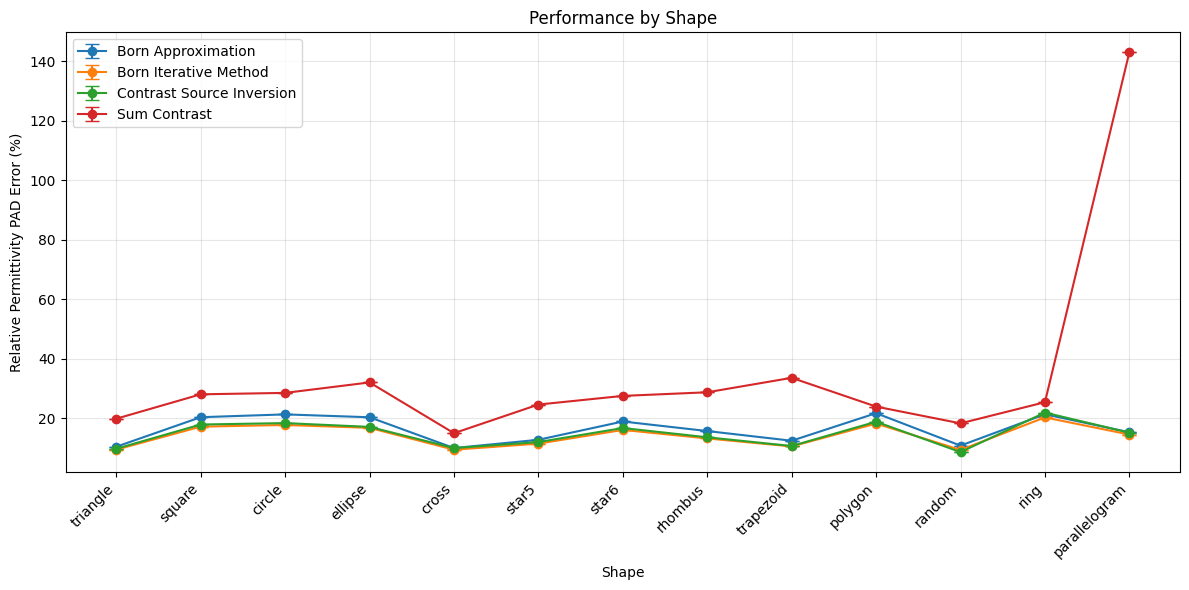

In [ ]:
indicator = rst.REL_PERMITTIVITY_PAD_ERROR
shape_indices = group_indices.get('shapes', [])

print("Shape configuration indices:", shape_indices)

if shape_indices:
    fig, ax = plt.subplots(figsize=(12, 6))
    has_data = False

    for a_idx, name in enumerate(algorithm_names):
        means = []
        stds = []
        labels = []

        for c_idx in shape_indices:
            data = get_indicator_data(a_idx, c_idx, indicator)
            valid = data[~np.isnan(data)]

            if len(valid) > 0:
                means.append(np.mean(valid))
                stds.append(np.std(valid))
                labels.append(configs[c_idx]['shape'])

        if means:
            has_data = True
            x = np.arange(len(means))
            ax.errorbar(
                x, means, yerr=stds,
                marker='o', label=name, capsize=5
            )

    if has_data:
        ax.set_xlabel('Shape')
        ax.set_ylabel('Relative Permittivity PAD Error (%)')
        ax.set_title('Performance by Shape')
        ax.set_xticks(np.arange(len(shape_indices)))
        ax.set_xticklabels(
            [configs[i]['shape'] for i in shape_indices],
            rotation=45, ha='right'
        )
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("No valid data available for shape analysis")
else:
    print("No shape configurations available")


## 4. Noise Level Analysis

In [ ]:
print(group_indices)
noise_indices = group_indices.get('noise', [])
print(noise_indices)

{'shapes': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 'noise': [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28], 'permittivity': [29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44], 'sources': [45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57]}
[13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]


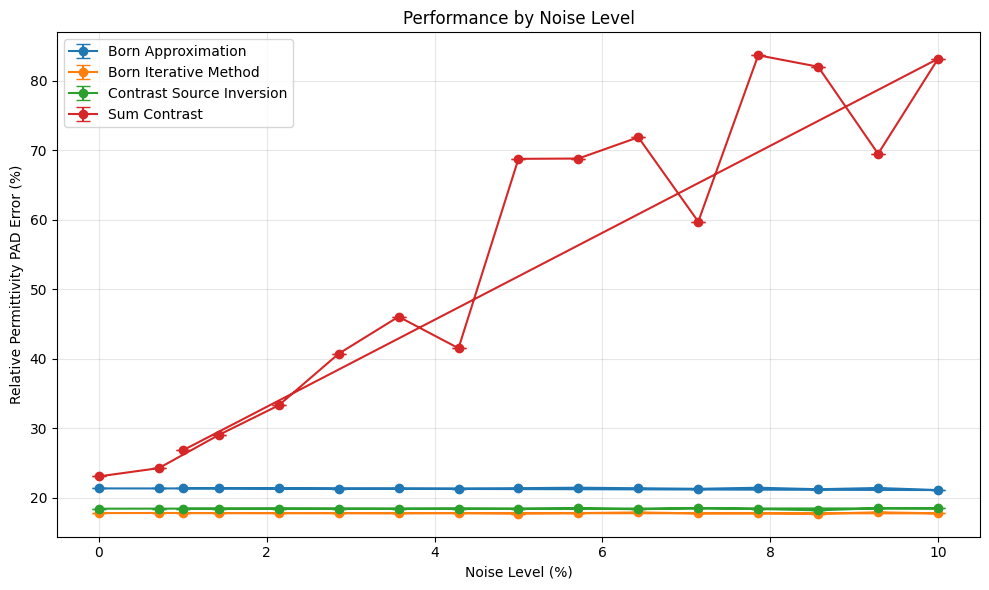

In [ ]:
indicator = rst.REL_PERMITTIVITY_PAD_ERROR
noise_indices = group_indices.get('noise', [])

if noise_indices:
    fig, ax = plt.subplots(figsize=(10, 6))
    has_data = False

    for a_idx, name in enumerate(algorithm_names):
        means = []
        stds = []
        x = []

        for c_idx in noise_indices:
            data = get_indicator_data(a_idx, c_idx, indicator)
            valid = data[~np.isnan(data)]

            if len(valid) > 0:
                means.append(np.mean(valid))
                stds.append(np.std(valid))
                x.append(configs[c_idx]['noise_level'])

        if means:
            has_data = True
            ax.errorbar(
                x, means, yerr=stds,
                marker='o', label=name, capsize=5, linestyle='-'
            )

    if has_data:
        ax.set_xlabel('Noise Level (%)')
        ax.set_ylabel('Relative Permittivity PAD Error (%)')
        ax.set_title('Performance by Noise Level')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("No valid data available for noise analysis")
else:
    print("No noise configurations available")


## 5. Permittivity Analysis

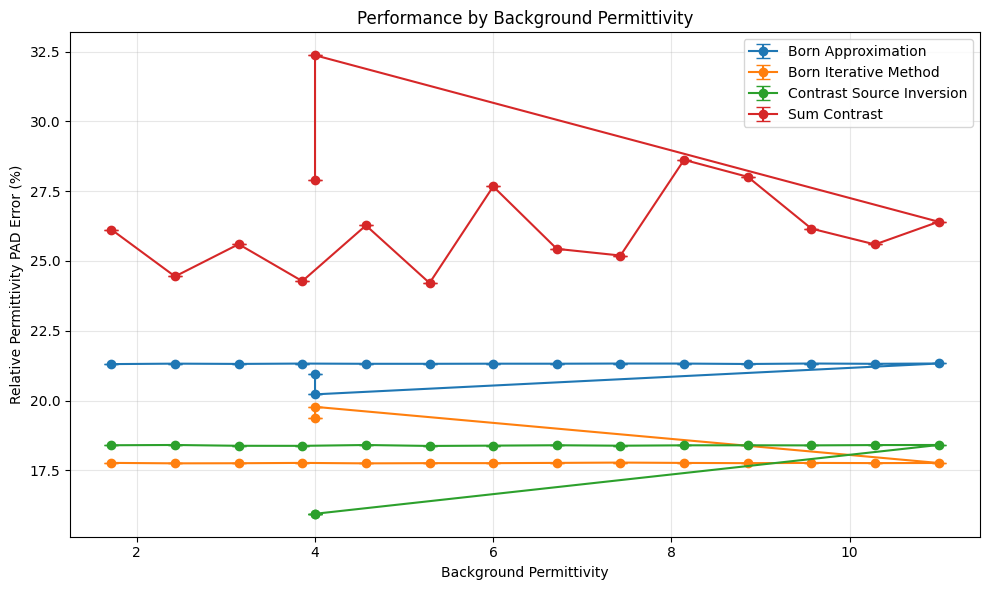

In [ ]:
indicator = rst.REL_PERMITTIVITY_PAD_ERROR
perm_indices = group_indices.get('permittivity', [])

if perm_indices:
    fig, ax = plt.subplots(figsize=(10, 6))
    has_data = False

    for a_idx, name in enumerate(algorithm_names):
        means = []
        stds = []
        x = []

        for c_idx in perm_indices:
            data = get_indicator_data(a_idx, c_idx, indicator)
            valid = data[~np.isnan(data)]

            if len(valid) > 0:
                means.append(np.mean(valid))
                stds.append(np.std(valid))
                x.append(configs[c_idx]['background_permittivity'])

        if means:
            has_data = True
            ax.errorbar(
                x, means, yerr=stds,
                marker='o', label=name, capsize=5, linestyle='-'
            )

    if has_data:
        ax.set_xlabel('Background Permittivity')
        ax.set_ylabel('Relative Permittivity PAD Error (%)')
        ax.set_title('Performance by Background Permittivity')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("No valid data available for permittivity analysis")
else:
    print("No permittivity configurations available")


## 6. Sources and Measurements Analysis

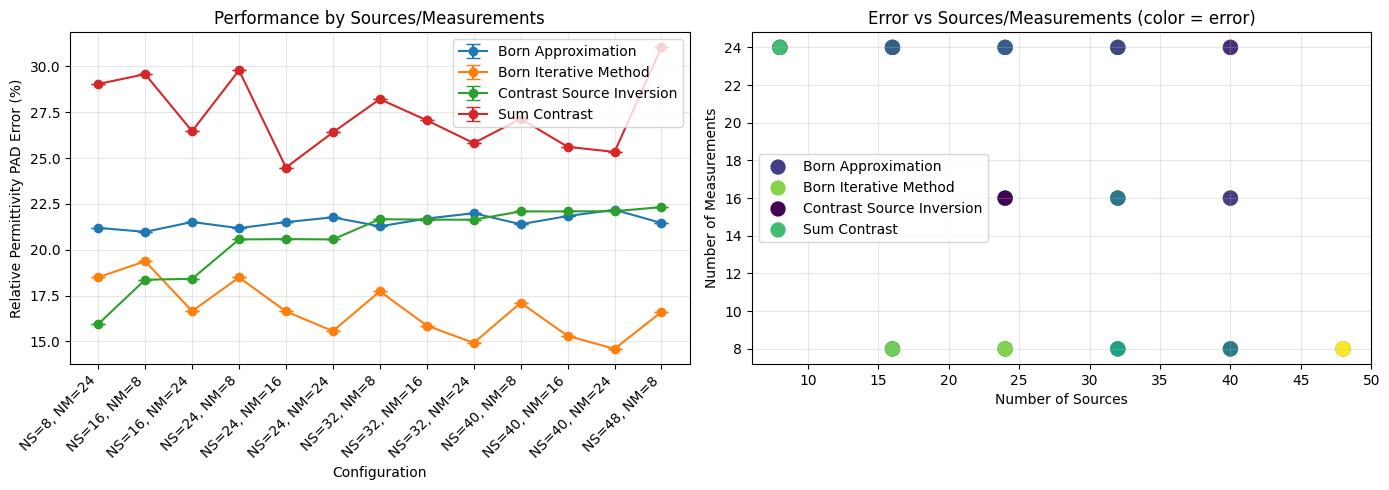

In [ ]:
indicator = rst.REL_PERMITTIVITY_PAD_ERROR
src_indices = group_indices.get('sources', [])

if src_indices:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    has_data = False

    # First plot: one point per source/measurement configuration.
    for a_idx, name in enumerate(algorithm_names):
        means = []
        stds = []
        labels = []

        for c_idx in src_indices:
            data = get_indicator_data(a_idx, c_idx, indicator)
            valid = data[~np.isnan(data)]

            if len(valid) > 0:
                means.append(np.mean(valid))
                stds.append(np.std(valid))
                labels.append(
                    f"NS={configs[c_idx]['number_sources']}, "
                    f"NM={configs[c_idx]['number_measurements']}"
                )

        if means:
            has_data = True
            x = np.arange(len(means))
            axes[0].errorbar(
                x, means, yerr=stds,
                marker='o', label=name, capsize=5
            )

    if has_data:
        axes[0].set_xlabel('Configuration')
        axes[0].set_ylabel('Relative Permittivity PAD Error (%)')
        axes[0].set_title('Performance by Sources/Measurements')
        axes[0].set_xticks(np.arange(len(src_indices)))
        axes[0].set_xticklabels(labels, rotation=45, ha='right')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Second plot: NS vs NM, with mean error represented by point color.
        for a_idx, name in enumerate(algorithm_names):
            ns = []
            nm = []
            errors = []

            for c_idx in src_indices:
                data = get_indicator_data(a_idx, c_idx, indicator)
                valid = data[~np.isnan(data)]

                if len(valid) > 0:
                    ns.append(configs[c_idx]['number_sources'])
                    nm.append(configs[c_idx]['number_measurements'])
                    errors.append(np.mean(valid))

            if errors:
                axes[1].scatter(
                    ns, nm, c=errors, s=100,
                    cmap='viridis', label=name
                )

        axes[1].set_xlabel('Number of Sources')
        axes[1].set_ylabel('Number of Measurements')
        axes[1].set_title('Error vs Sources/Measurements (color = error)')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
    else:
        print("No valid data available for sources/measurements analysis")
else:
    print("No sources/measurements configurations available")


## 7. Best Configuration per Algorithm

In [ ]:
indicator = rst.REL_PERMITTIVITY_PAD_ERROR

print("\n=== Best Configuration per Algorithm ===\n")

for a_idx, name in enumerate(algorithm_names):
    best_val = np.inf
    best_idx = -1

    for c_idx in range(n_configs):
        data = get_indicator_data(a_idx, c_idx, indicator)
        valid = data[~np.isnan(data)]

        if len(valid) == 0:
            continue

        mean_val = np.mean(valid)

        if mean_val < best_val:
            best_val = mean_val
            best_idx = c_idx

    if best_idx >= 0:
        print(f"{name}:")
        print(f"  Best config index: {best_idx}")
        print(f"  Best config: {get_config_label(configs[best_idx])}")
        print(f"  Mean error: {best_val:.4f}")
        print()
    else:
        print(f"{name}: no valid data")



=== Best Configuration per Algorithm ===

Born Approximation:
  Best config index: 4
  Best config: shape=cross, eps=4.0, NM=16, NS=16, noise=1.0
  Mean error: 9.9788

Born Iterative Method:
  Best config index: 10
  Best config: shape=random, eps=4.0, NM=16, NS=16, noise=1.0
  Mean error: 9.3497

Contrast Source Inversion:
  Best config index: 10
  Best config: shape=random, eps=4.0, NM=16, NS=16, noise=1.0
  Mean error: 8.6313

Sum Contrast:
  Best config index: 4
  Best config: shape=cross, eps=4.0, NM=16, NS=16, noise=1.0
  Mean error: 14.9796



## 8. Overall Best Algorithm per Configuration

In [ ]:
indicator = rst.REL_PERMITTIVITY_PAD_ERROR

print("\n=== Best Algorithm per Configuration ===\n")

for c_idx in range(n_configs):
    print(f"Config {c_idx}: {get_config_label(configs[c_idx])}")

    best_algo = -1
    best_val = np.inf

    for a_idx, name in enumerate(algorithm_names):
        data = get_indicator_data(a_idx, c_idx, indicator)
        valid = data[~np.isnan(data)]

        if len(valid) == 0:
            print(f"  {name}: no valid data")
            continue

        mean_val = np.mean(valid)
        print(f"  {name}: {mean_val:.4f}")

        if mean_val < best_val:
            best_val = mean_val
            best_algo = a_idx

    if best_algo >= 0:
        print(f"  Best: {algorithm_names[best_algo]} ({best_val:.4f})")
    else:
        print("  Best: no valid data")

    print()



=== Best Algorithm per Configuration ===

Config 0: shape=triangle, eps=4.0, NM=16, NS=16, noise=1.0
  Born Approximation: 10.4338
  Born Iterative Method: 9.4560
  Contrast Source Inversion: 9.7511
  Sum Contrast: 19.8509
  Best: Born Iterative Method (9.4560)

Config 1: shape=square, eps=4.0, NM=16, NS=16, noise=1.0
  Born Approximation: 20.3594
  Born Iterative Method: 17.1805
  Contrast Source Inversion: 17.8965
  Sum Contrast: 28.0535
  Best: Born Iterative Method (17.1805)

Config 2: shape=circle, eps=4.0, NM=16, NS=16, noise=1.0
  Born Approximation: 21.3025
  Born Iterative Method: 17.7441
  Contrast Source Inversion: 18.3758
  Sum Contrast: 28.5303
  Best: Born Iterative Method (17.7441)

Config 3: shape=ellipse, eps=4.0, NM=16, NS=16, noise=1.0
  Born Approximation: 20.3377
  Born Iterative Method: 16.7741
  Contrast Source Inversion: 17.0962
  Sum Contrast: 32.0489
  Best: Born Iterative Method (16.7741)

Config 4: shape=cross, eps=4.0, NM=16, NS=16, noise=1.0
  Born Approx

## 9. Summary Statistics

In [ ]:
indicator = rst.REL_PERMITTIVITY_PAD_ERROR

print("\n=== Summary Statistics ===\n")

for a_idx, name in enumerate(algorithm_names):
    all_data = []

    for c_idx in range(n_configs):
        data = get_indicator_data(a_idx, c_idx, indicator)
        valid = data[~np.isnan(data)]
        all_data.extend(valid)

    if all_data:
        all_data = np.asarray(all_data)

        print(f"{name}:")
        print(f"  Mean: {np.mean(all_data):.4f}")
        print(f"  Std: {np.std(all_data):.4f}")
        print(f"  Min: {np.min(all_data):.4f}")
        print(f"  Max: {np.max(all_data):.4f}")
        print(f"  N: {len(all_data)}")
        print()
    else:
        print(f"{name}: no valid data\n")



=== Summary Statistics ===

Born Approximation:
  Mean: 20.2048
  Std: 2.9862
  Min: 9.9788
  Max: 22.1831
  N: 58

Born Iterative Method:
  Mean: 16.7852
  Std: 2.4030
  Min: 9.3497
  Max: 20.2935
  N: 58

Contrast Source Inversion:
  Mean: 17.9693
  Std: 2.9433
  Min: 8.6313
  Max: 22.3275
  N: 58

Sum Contrast:
  Mean: 35.8778
  Std: 21.9624
  Min: 14.9796
  Max: 143.0626
  N: 58



## 10. Boxplot by Configuration Group

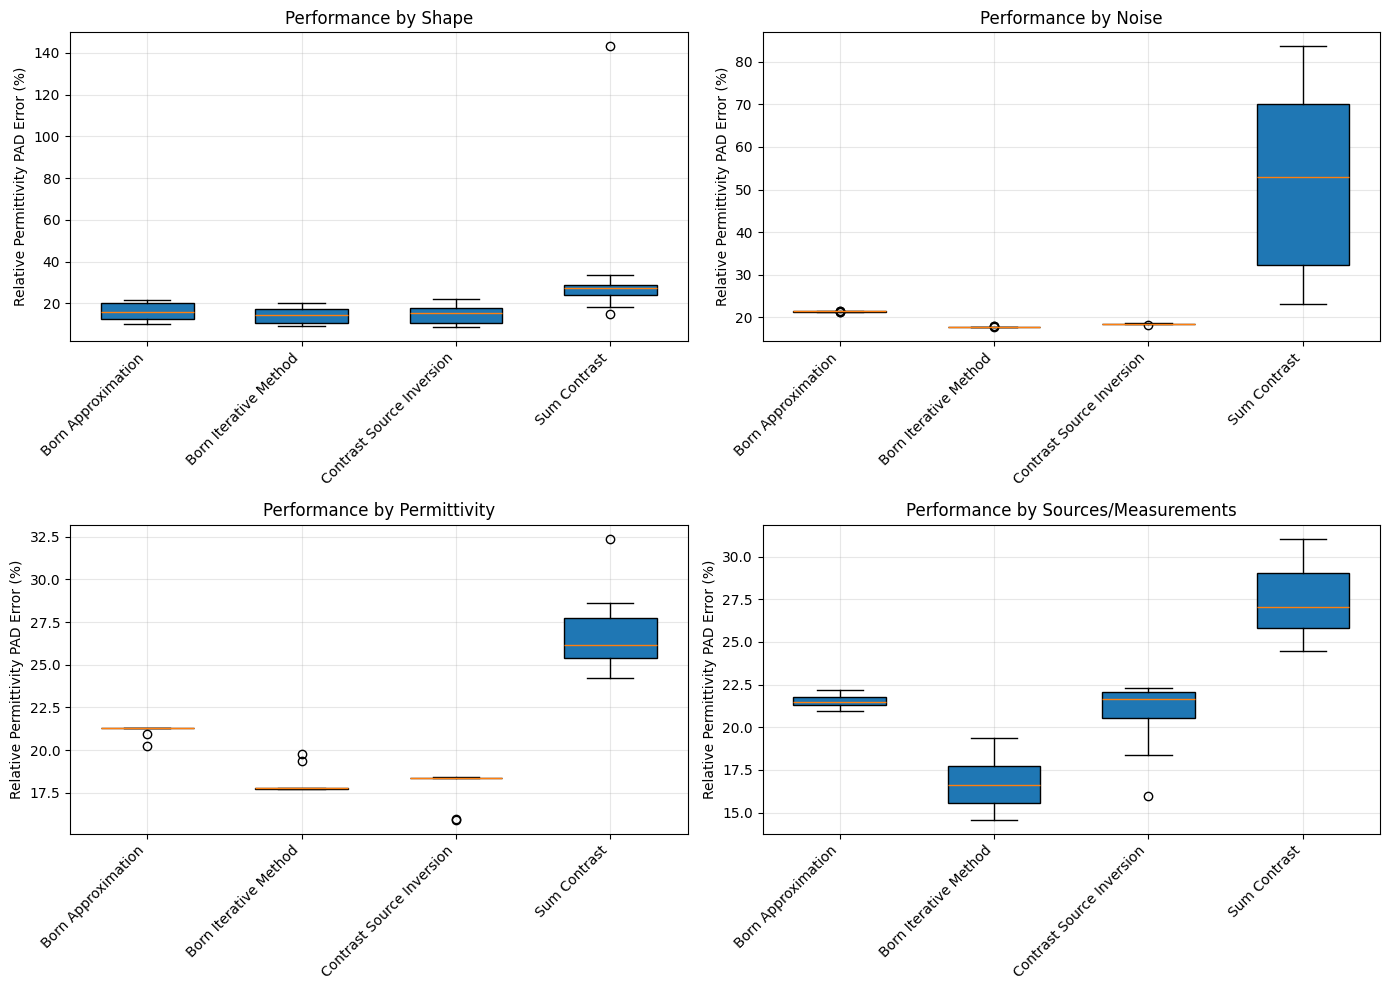

In [ ]:
indicator = rst.REL_PERMITTIVITY_PAD_ERROR

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

group_configs = [
    ('Shape', group_indices.get('shapes', [])),
    ('Noise', group_indices.get('noise', [])),
    ('Permittivity', group_indices.get('permittivity', [])),
    ('Sources/Measurements', group_indices.get('sources', []))
]

for idx, (group_name, indices) in enumerate(group_configs):
    ax = axes[idx]
    has_data = False

    if indices:
        for a_idx, name in enumerate(algorithm_names):
            data = []

            for c_idx in indices:
                d = get_indicator_data(a_idx, c_idx, indicator)
                valid = d[~np.isnan(d)]
                data.extend(valid)

            if len(data) > 0:
                has_data = True
                ax.boxplot(
                    data,
                    positions=[a_idx + 1],
                    widths=0.6,
                    patch_artist=True
                )

        if has_data:
            ax.set_xticks(range(1, len(algorithm_names) + 1))
            ax.set_xticklabels(
                algorithm_names,
                rotation=45,
                ha='right'
            )
            ax.set_ylabel('Relative Permittivity PAD Error (%)')
            ax.set_title(f'Performance by {group_name}')
            ax.grid(True, alpha=0.3)
        else:
            ax.text(
                0.5, 0.5,
                f'No data for {group_name}',
                ha='center', va='center'
            )
            ax.set_title(f'Performance by {group_name}')
    else:
        ax.text(
            0.5, 0.5,
            f'No {group_name} configurations',
            ha='center', va='center'
        )
        ax.set_title(f'Performance by {group_name}')

plt.tight_layout()
plt.show()


## 11. Conclusion
